<a href="https://colab.research.google.com/github/f-hnv/ActividadMachineLearning/blob/main/regresion_polinomial_12_sep_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.formula.api as smf
import pandas as pd

# Creacion de la data

In [37]:
X = np.random.rand(300,1)
Y = 4*X**2 - 2*X + 3 + np.random.rand(300,1)
print(X.shape)
print(Y.shape)

# Lo pasamos a DataFrame para verlo bonito
df = pd.DataFrame({'x': X.flatten(), 'y': Y.flatten()})
print(df.head())

(300, 1)
(300, 1)
          x         y
0  0.004627  3.286905
1  0.633707  3.377259
2  0.297118  2.861660
3  0.192154  3.514536
4  0.145617  2.991790


<b> Tenemos arreglos bidimensionales que se pueden interpretar como matrices <b>

# Graficar los puntos

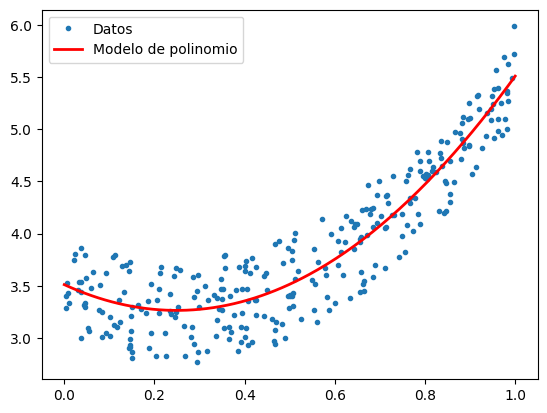

In [51]:
plt.plot(X, Y, '.', label='Datos')
plt.plot(x_curva, y_curva, 'r-', linewidth=2, label='Modelo de polinomio')
plt.legend()
plt.show()


"La curva roja es el polinomio de grado 2 que ajustó el modelo. Sigue la tendencia de los datos, con una leve bajada inicial y un crecimiento acelerado después. Luego los puntos se distribuyen de forma pareja alrededor de la curva, lo que nos da entender o lo que indica que el error restante es ruido aleatorio. Los coeficientes estimados (−1.98 y 3.98) casi coinciden con los de la función original (−2 y 4), y el R² de 0.87 indica que el modelo explica la mayor parte de la variación."

# Construya un modelo polinomial que pueda estimar los valores de la fdistribucion anterior


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['x']], df[['y']], test_size=0.2, random_state=42
)

In [39]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)   # fit solo con train
X_test_poly = poly.transform(X_test) #Hago el transform en el test solamente

Entreno el modelo

In [40]:
modelo = LinearRegression()
modelo.fit(X_train_poly, y_train)

LinearRegression()

Aca hago las predicciones

In [41]:
y_pred = modelo.predict(X_test_poly)
print("Coeficientes [x, x²]:", modelo.coef_[0])
print("Intersección (b):", modelo.intercept_[0])
print("R² score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Coeficientes [x, x²]: [-1.98458598  3.98423751]
Intersección (b): 3.5103017416826505
R² score: 0.8704291522930213
MSE: 0.0712443502008052


In [42]:
x_curva = pd.DataFrame({'x': np.linspace(0, 1, 200)})
y_curva = modelo.predict(poly.transform(x_curva))

Testeo aparte

In [44]:
mses = []
for seed in range(200):
    Xtr, Xte, ytr, yte = train_test_split(df[['x']], df[['y']], test_size=0.2, random_state=seed)
    p = PolynomialFeatures(degree=2, include_bias=False)
    m = LinearRegression().fit(p.fit_transform(Xtr), ytr)
    mses.append(mean_squared_error(yte, m.predict(p.transform(Xte))))

print("MSE promedio:", np.mean(mses))
print("MSE mínimo y máximo:", np.min(mses), np.max(mses))

MSE promedio: 0.07449210211730808
MSE mínimo y máximo: 0.05367904720454254 0.10093602144480364


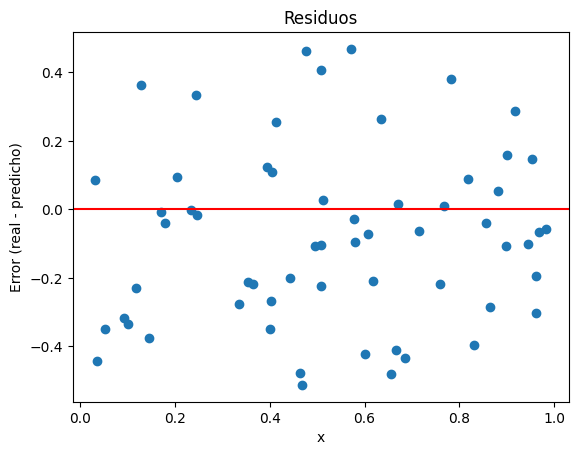

In [53]:
   residuos = y_test.values.flatten() - y_pred.flatten()
   plt.scatter(X_test['x'], residuos)
   plt.axhline(0, color='red')
   plt.xlabel('x'); plt.ylabel('Error (real - predicho)')
   plt.title('Residuos')
   plt.show()